# Improved Models

This notebook uses the engineered modeling table and compares three model families: Random Forest, XGBoost, and a Keras neural network. The final model is selected on 2025 validation performance, then refit through 2025 and tested on 2026.

### Setup


In [ ]:
from pathlib import Path
import gc
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import keras
import tensorflow as tf
from keras import layers, regularizers

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    f1_score,
    log_loss,
    precision_recall_fscore_support,
    recall_score,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

ROOT = Path.cwd().resolve()
if not (ROOT / "data").exists():
    ROOT = ROOT.parent

CONFIG = json.loads(
    (ROOT / "config/project_config.json").read_text(encoding="utf-8")
)
keras.utils.set_random_seed(CONFIG["seed"])

LABELS = CONFIG["bin_labels"]
CLASSES = np.arange(len(LABELS))
PRIMARY_HORIZON = int(CONFIG["primary_horizon"])
COMPARISON_HORIZON = int(CONFIG["comparison_horizon"])
VALIDATION_START_DATE = pd.Timestamp(CONFIG["validation_start_date"])
TEST_START_DATE = pd.Timestamp(CONFIG["test_start_date"])

primary_data = pd.read_parquet(
    ROOT / f"data/modeling/sfo_delay_features_{PRIMARY_HORIZON}h.parquet"
)
primary_data = primary_data.loc[primary_data["target_delay_bin"].notna()]


### Temporal split

Keep model selection and final testing separated by calendar time.

In [2]:
train = primary_data.loc[primary_data["flight_date"] < VALIDATION_START_DATE].copy()
validation = primary_data.loc[
    (primary_data["flight_date"] >= VALIDATION_START_DATE)
    & (primary_data["flight_date"] < TEST_START_DATE)
].copy()
test = primary_data.loc[primary_data["flight_date"] >= TEST_START_DATE].copy()

splits = {
    "Train": train,
    "Validation": validation,
    "Test": test,
}
split_summary = pd.DataFrame(
    {
        "split": list(splits.keys()),
        "rows": [len(frame) for frame in splits.values()],
        "start_date": [
            frame["flight_date"].min().date()
            for frame in splits.values()
        ],
        "end_date": [
            frame["flight_date"].max().date()
            for frame in splits.values()
        ],
    }
)
display(split_summary)

,split,rows,start_date,end_date
0,Train,293770,2022-01-01,2024-12-31
1,Validation,109971,2025-01-01,2025-12-31
2,Test,45646,2026-01-01,2026-05-31


### Tail-aware feature selection

Tail number is assumed to be known at the configured primary cutoff. Previous-flight actual values are still only used when that previous event happened before the cutoff.

Feature selection:

- remove IDs, targets, cancellations, and current-flight delay causes;
- remove FAA aircraft fields because prior tests did not show useful lift;
- remove columns with at least 90% missing values in training.

In [3]:
NON_FEATURES = {
    "flight_id", "flight_date", "scheduled_dep_utc",
    "prediction_cutoff_utc", "prediction_horizon_hours",
    "dep_delay_minutes", "cancelled", "target_cancelled",
    "target_delay_ge_15", "target_delay_bin", "target_delay_bin_label",
    "eda_only_carrier_delay_minutes", "eda_only_weather_delay_minutes",
    "eda_only_nas_delay_minutes", "eda_only_security_delay_minutes",
    "eda_only_late_aircraft_delay_minutes",
}
FAA_FEATURES = {
    "aircraft_year_manufactured", "aircraft_type_code", "engine_type_code",
    "aircraft_manufacturer", "aircraft_model", "number_of_engines",
    "number_of_seats", "aircraft_weight_class", "aircraft_cruise_speed",
    "engine_thrust", "faa_record_type", "aircraft_age_years",
    "faa_match_flag",
}
LINEAGE_FEATURES = {
    "tail_sequence_today", "has_previous_tail_flight",
    "previous_flight_matches_origin", "previous_arrived_by_cutoff",
    "previous_departed_by_cutoff", "previous_arrival_delay_known",
    "previous_departure_delay_known", "scheduled_turnaround_minutes",
    "minutes_until_previous_scheduled_arrival",
    "minutes_since_previous_actual_arrival",
}

candidates = [column for column in train.columns if column not in NON_FEATURES]
training_missingness = 100 * train[candidates].isna().mean()
high_missing_features = training_missingness.loc[training_missingness >= 90].index.tolist()

FEATURES = [
    feature
    for feature in candidates
    if feature not in FAA_FEATURES
    and feature not in high_missing_features
]
CATEGORICAL_FEATURES = [
    feature
    for feature in FEATURES
    if pd.api.types.is_object_dtype(train[feature])
    or pd.api.types.is_string_dtype(train[feature])
]
NUMERIC_FEATURES = [feature for feature in FEATURES if feature not in CATEGORICAL_FEATURES]

feature_summary = pd.DataFrame(
    {
        "value": [
            len(candidates),
            len(high_missing_features),
            len(FAA_FEATURES.intersection(candidates)),
            len(FEATURES),
            len(LINEAGE_FEATURES.intersection(FEATURES)),
        ]
    },
    index=[
        "candidate features",
        "removed for missingness",
        "FAA features excluded",
        "final model features",
        "same-tail features retained",
    ],
)

display(feature_summary)
high_missing_table = training_missingness.reindex(high_missing_features)
high_missing_table = high_missing_table.sort_values(ascending=False).rename("missing_percent").round(2).to_frame()
display(high_missing_table)


,value
candidate features,167
removed for missingness,2
FAA features excluded,13
final model features,152
same-tail features retained,10


,missing_percent
origin_wind_gust_mps,90.33
origin_wind_gust_excess_mps,90.33


### Missing values and preprocessing

Rows are not dropped for missing predictors. 

Median and most-frequent imputation are fitted on Train only. 

Missing same-tail delays are meaningful because companion flags indicate whether the previous event was known by cutoff.

This is why rows are not dropped just because a lineage value is missing. For example, a missing prior-arrival delay often means the previous aircraft has not arrived yet, which is itself captured by `previous_arrived_by_cutoff`.


In [4]:
selected_missingness = (100 * train[FEATURES].isna().mean()).sort_values(ascending=False)
selected_missingness = selected_missingness.loc[selected_missingness.gt(0)]
display(selected_missingness.rename("missing_percent").round(2).to_frame())

,missing_percent
origin_wind_gust_max_prior_3h,78.81
previous_arrival_delay_known,62.21
minutes_since_previous_actual_arrival,62.21
carrier_destination_departures_delay_mean_6h,41.87
carrier_destination_departures_delay_ge_15_rate_6h,41.87
origin_precipitation_mm,26.37
origin_altimeter_hpa,21.45
carrier_sfo_arrivals_delay_mean_3h,18.23
carrier_sfo_arrivals_delay_ge_15_rate_3h,18.23
carrier_sfo_departures_delay_mean_3h,13.56


In [5]:
def prepare_model_data(frame):
    model_data = frame[FEATURES].copy()

    model_data[NUMERIC_FEATURES] = model_data[NUMERIC_FEATURES].apply(
        pd.to_numeric,
        errors="coerce",
    ).astype("float32")
    for column in CATEGORICAL_FEATURES:
        model_data[column] = model_data[column].astype(object).where(
            model_data[column].notna(),
            np.nan,
        )
    return model_data


def build_preprocessor():
    numeric_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scale", StandardScaler(with_mean=False)),
        ]
    )
    categorical_pipeline = Pipeline(
        [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="infrequent_if_exist",
                    min_frequency=25,
                    dtype=np.float32,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        [
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        sparse_threshold=1.0,
    )


development_preprocessor = build_preprocessor()
X_train = development_preprocessor.fit_transform(
    prepare_model_data(train)
).astype("float32")
X_validation = development_preprocessor.transform(
    prepare_model_data(validation)
).astype("float32")

y_train = train["target_delay_bin"].astype(int).to_numpy()
y_validation = validation["target_delay_bin"].astype(int).to_numpy()

transformed_summary = pd.DataFrame(
    {
        "rows": [X_train.shape[0], X_validation.shape[0]],
        "encoded_features": [X_train.shape[1], X_validation.shape[1]],
    },
    index=["Train", "Validation"],
)
display(transformed_summary)

,rows,encoded_features
Train,293770,219
Validation,109971,219


### Class weights and evaluation

Use the same square-root class weights and scoring functions as the baseline notebook.

In [6]:
def make_sample_weights(y):
    balanced = compute_class_weight(
        "balanced",
        classes=CLASSES,
        y=y,
    )
    return np.sqrt(balanced)[y]


def score_predictions(actual, probabilities):
    predicted = probabilities.argmax(axis=1)
    actual_severe = np.isin(actual, [3, 4])
    predicted_severe = np.isin(predicted, [3, 4])

    return {
        "accuracy": accuracy_score(actual, predicted),
        "balanced_accuracy": balanced_accuracy_score(actual, predicted),
        "macro_f1": f1_score(
            actual, predicted, average="macro", zero_division=0
        ),
        "log_loss": log_loss(actual, probabilities, labels=CLASSES),
        "within_one_bin": np.mean(np.abs(actual - predicted) <= 1),
        "severe_recall": recall_score(
            actual_severe, predicted_severe, zero_division=0
        ),
    }


training_weights = make_sample_weights(y_train)


### Define the improved models

In [7]:
random_forest = RandomForestClassifier(
    n_estimators=140,
    max_depth=18,
    min_samples_leaf=5,           # Minimum training samples required in each leaf
    max_features="sqrt",          # sqrt(total features) at each split
    n_jobs=-1,
    random_state=CONFIG["seed"],
)

xgboost = XGBClassifier(
    objective="multi:softprob",   # Multiclass classification with class probabilities
    num_class=len(CLASSES),       
    n_estimators=180,             
    max_depth=6,                  
    learning_rate=0.06,           
    subsample=0.85,               # Use 85% of training rows for each tree
    colsample_bytree=0.85,        # Use 85% of features for each tree
    min_child_weight=5,          
    reg_lambda=2,                 # L2 regularization to reduce overfitting
    eval_metric="mlogloss",       
    n_jobs=-1,                    
    random_state=CONFIG["seed"],  
)

def build_neural_network(input_width):
    keras.utils.set_random_seed(CONFIG["seed"])
    neural_network = keras.Sequential(
        [
            keras.Input(shape=(input_width,)),
            layers.Dense(
                96,
                activation="relu",
                kernel_regularizer=regularizers.L2(0.0002),
            ),
            layers.Dense(
                48,
                activation="relu",
                kernel_regularizer=regularizers.L2(0.0002),
            ),
            layers.Dense(len(CLASSES), activation="softmax"),
        ],
        name="flight_delay_mlp",
    )
    neural_network.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return neural_network

def fit_neural_network(
    X_fit,
    y_fit,
    X_holdout,
    y_holdout,
    fit_weights=None,
    holdout_weights=None,
):
    X_fit_dense = (
        X_fit.toarray().astype("float32")
        if hasattr(X_fit, "toarray")
        else np.asarray(X_fit, dtype="float32")
    )
    X_holdout_dense = (
        X_holdout.toarray().astype("float32")
        if hasattr(X_holdout, "toarray")
        else np.asarray(X_holdout, dtype="float32")
    )

    neural_network = build_neural_network(X_fit_dense.shape[1])
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    )

    validation_data = (X_holdout_dense, y_holdout)
    if holdout_weights is not None:
        validation_data = (X_holdout_dense, y_holdout, holdout_weights)

    history = neural_network.fit(
        X_fit_dense,
        y_fit,
        sample_weight=fit_weights,
        validation_data=validation_data,
        epochs=30,
        batch_size=1024,
        callbacks=[early_stopping],
        verbose=0,
    )
    fit_probabilities = neural_network.predict(
        X_fit_dense,
        batch_size=4096,
        verbose=0,
    )
    holdout_probabilities = neural_network.predict(
        X_holdout_dense,
        batch_size=4096,
        verbose=0,
    )

    # Deleting due to MemoryError
    del X_fit_dense, X_holdout_dense
    gc.collect()
    return neural_network, history, fit_probabilities, holdout_probabilities

### Train on 2022-2024 and evaluate on 2025

The three models are trained separately below so the workflow is easy to trace.

In [8]:
fitted_models = {}
validation_probabilities = {}
keras_histories = {}
development_rows = []

def add_scores(model_name, train_probabilities, validation_probability):
    validation_probabilities[model_name] = validation_probability
    for split_name, actual, probabilities in [
        ("Train", y_train, train_probabilities),
        ("Validation", y_validation, validation_probability),
    ]:
        development_rows.append(
            {
                "model": model_name,
                "split": split_name,
                **score_predictions(actual, probabilities),
            }
        )

rf_model = clone(random_forest)
rf_model.fit(X_train, y_train, sample_weight=training_weights)
fitted_models["Random Forest"] = rf_model
add_scores(
    "Random Forest",
    rf_model.predict_proba(X_train),
    rf_model.predict_proba(X_validation),
)

xgb_model = clone(xgboost)
xgb_model.fit(
    X_train,
    y_train,
    sample_weight=training_weights,
    eval_set=[(X_train, y_train), (X_validation, y_validation)],
    verbose=False,
)
fitted_models["XGBoost"] = xgb_model
add_scores(
    "XGBoost",
    xgb_model.predict_proba(X_train),
    xgb_model.predict_proba(X_validation),
)

validation_weights = make_sample_weights(y_validation)
(
    neural_network,
    neural_network_history,
    neural_train_probabilities,
    neural_validation_probabilities,
) = fit_neural_network(
    X_train,
    y_train,
    X_validation,
    y_validation,
    fit_weights=training_weights,
    holdout_weights=validation_weights,
)
fitted_models["Neural Network"] = neural_network
keras_histories["Neural Network"] = neural_network_history
add_scores(
    "Neural Network",
    neural_train_probabilities,
    neural_validation_probabilities,
)

models = {
    "Random Forest": random_forest,
    "XGBoost": xgboost,
    "Neural Network": "keras",
}

development_results = pd.DataFrame(development_rows)
display(development_results.set_index(["model", "split"]).round(4))

accuracy  balanced_accuracy  macro_f1  log_loss  \
model          split                                                         
Random Forest  Train         0.9030             0.7765    0.8362    0.4779   
               Validation    0.8339             0.3598    0.4142    0.6342   
XGBoost        Train         0.8349             0.5590    0.6092    0.5645   
               Validation    0.8387             0.4429    0.4876    0.5745   
Neural Network Train         0.7902             0.3949    0.4027    0.7095   
               Validation    0.8153             0.3864    0.3992    0.6582   

                           within_one_bin  severe_recall  
model          split                                      
Random Forest  Train               0.9799         0.8055  
               Validation          0.9601         0.1993  
XGBoost        Train               0.9694         0.5079  
               Validation          0.9657         0.3456  
Neural Network Train               0.9508         0.3489  
               Validation          0.9511         0.3313

### Train-validation gaps and model selection

XGBoost is selected only if it provides the strongest validation performance without an unreasonable train-validation gap. The test data remain untouched.

The validation year is used for model choice. The 2026 test period should be read as the final holdout, so repeated decisions should not be made from the test table.


,train_accuracy,validation_accuracy,accuracy_gap,train_log_loss,validation_log_loss,log_loss_gap,validation_macro_f1,validation_balanced_accuracy,validation_severe_recall
model,,,,,,,,,
XGBoost,0.8349,0.8387,-0.0038,0.5645,0.5745,0.0099,0.4876,0.4429,0.3456
Random Forest,0.9030,0.8339,0.0691,0.4779,0.6342,0.1563,0.4142,0.3598,0.1993
Neural Network,0.7902,0.8153,-0.0251,0.7095,0.6582,-0.0513,0.3992,0.3864,0.3313


Selected from 2025 validation results: XGBoost


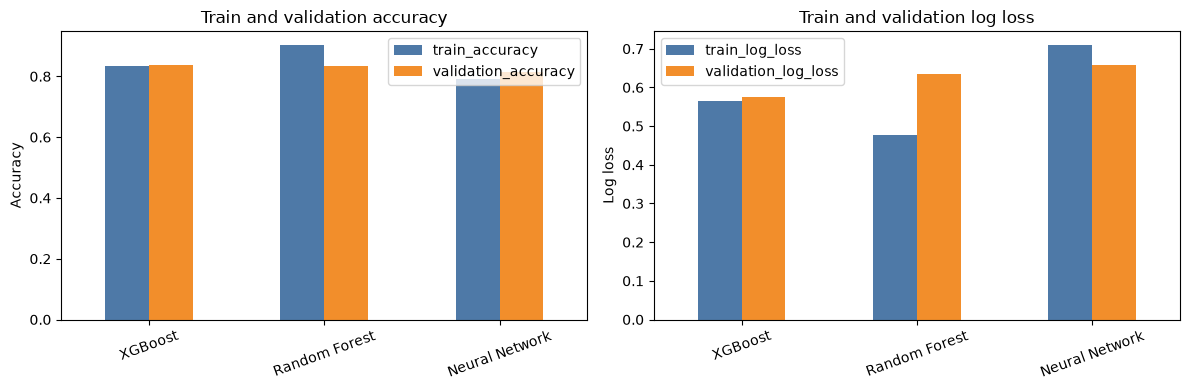

In [9]:
comparison_rows = []
for model_name in ["Random Forest", "XGBoost", "Neural Network"]:
    model_scores = development_results.loc[
        development_results["model"].eq(model_name)
    ].set_index("split")
    comparison_rows.append(
        {
            "model": model_name,
            "train_accuracy": model_scores.loc["Train", "accuracy"],
            "validation_accuracy": model_scores.loc[
                "Validation", "accuracy"
            ],
            "accuracy_gap": model_scores.loc["Train", "accuracy"]
            - model_scores.loc["Validation", "accuracy"],
            "train_log_loss": model_scores.loc["Train", "log_loss"],
            "validation_log_loss": model_scores.loc[
                "Validation", "log_loss"
            ],
            "log_loss_gap": model_scores.loc["Validation", "log_loss"]
            - model_scores.loc["Train", "log_loss"],
            "validation_macro_f1": model_scores.loc[
                "Validation", "macro_f1"
            ],
            "validation_balanced_accuracy": model_scores.loc[
                "Validation", "balanced_accuracy"
            ],
            "validation_severe_recall": model_scores.loc[
                "Validation", "severe_recall"
            ],
        }
    )

model_comparison = pd.DataFrame(comparison_rows).set_index("model")
model_comparison = model_comparison.sort_values(
    ["validation_macro_f1", "validation_log_loss"],
    ascending=[False, True],
)
selected_model_name = model_comparison.index[0]

display(model_comparison.round(4))
print("Selected from 2025 validation results:", selected_model_name)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
model_comparison[["train_accuracy", "validation_accuracy"]].plot.bar(
    ax=axes[0],
    color=["#4E79A7", "#F28E2B"],
)
axes[0].set_title("Train and validation accuracy")
axes[0].set_ylabel("Accuracy")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=20)

model_comparison[["train_log_loss", "validation_log_loss"]].plot.bar(
    ax=axes[1],
    color=["#4E79A7", "#F28E2B"],
)
axes[1].set_title("Train and validation log loss")
axes[1].set_ylabel("Log loss")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### XGBoost log-loss curve

XGBoost records multiclass log loss after every boosting round. A widening distance between the curves would indicate increasing overfitting.


,training_log_loss,validation_log_loss
boosting_round,,
176,0.5657,0.5740
177,0.5654,0.5740
178,0.5651,0.5744
179,0.5648,0.5747
180,0.5645,0.5745


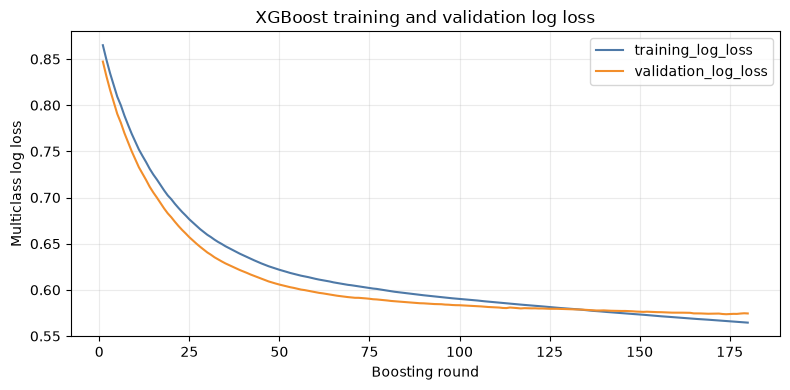

In [10]:
xgb_history = fitted_models["XGBoost"].evals_result()
xgb_learning_curve = pd.DataFrame(
    {
        "training_log_loss": xgb_history["validation_0"]["mlogloss"],
        "validation_log_loss": xgb_history["validation_1"]["mlogloss"],
    }
)
xgb_learning_curve.index = xgb_learning_curve.index + 1
xgb_learning_curve.index.name = "boosting_round"

display(xgb_learning_curve.tail().round(4))
xgb_learning_curve.plot(
    figsize=(8, 4),
    color=["#4E79A7", "#F28E2B"],
)
plt.ylabel("Multiclass log loss")
plt.xlabel("Boosting round")
plt.title("XGBoost training and validation log loss")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Confusion matrix for XGBoost


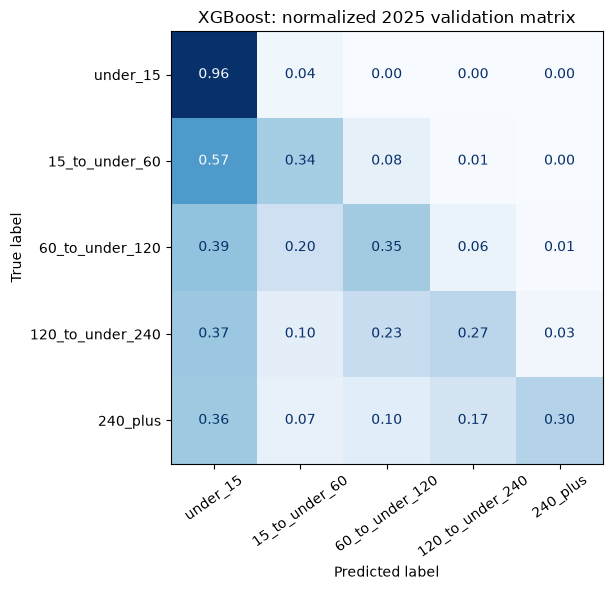

In [11]:
selected_validation_probabilities = validation_probabilities[selected_model_name]
selected_validation_predictions = selected_validation_probabilities.argmax(axis=1)

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    selected_validation_predictions,
    labels=CLASSES,
    display_labels=LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=35,
    colorbar=False,
    ax=ax,
)
ax.set_title(f"{selected_model_name}: normalized 2025 validation matrix")
plt.tight_layout()
plt.show()


### Final selected model test

After model selection, refit the selected model through 2025 and evaluate once on 2026.

This is the only place the selected model is evaluated on 2026. Refit through 2025 gives the model more recent training data after the model family has already been chosen.


In [12]:
final_train = primary_data.loc[primary_data["flight_date"] < TEST_START_DATE]
y_final_train = final_train["target_delay_bin"].astype(int).to_numpy()
y_test = test["target_delay_bin"].astype(int).to_numpy()

final_preprocessor = build_preprocessor()
X_final_train = final_preprocessor.fit_transform(
    prepare_model_data(final_train)
).astype("float32")
X_test = final_preprocessor.transform(
    prepare_model_data(test)
).astype("float32")

if selected_model_name == "Neural Network":
    (
        final_model,
        _,
        final_train_probabilities,
        selected_test_probabilities,
    ) = fit_neural_network(
        X_final_train,
        y_final_train,
        X_test,
        y_test,
        fit_weights=make_sample_weights(y_final_train),
        holdout_weights=make_sample_weights(y_test),
    )
else:
    final_model = clone(models[selected_model_name])
    final_model.fit(
        X_final_train,
        y_final_train,
        sample_weight=make_sample_weights(y_final_train),
    )
    final_train_probabilities = final_model.predict_proba(X_final_train)
    selected_test_probabilities = final_model.predict_proba(X_test)

final_rows = []
for split_name, actual, probabilities in [
    ("Train + Validation", y_final_train, final_train_probabilities),
    ("Test", y_test, selected_test_probabilities),
]:
    row = {"split": split_name}
    row.update(score_predictions(actual, probabilities))
    final_rows.append(row)

selected_final_results = pd.DataFrame(final_rows).set_index("split")
train_test_gap = pd.DataFrame(
    {
        "value": [
            selected_final_results.loc[
                "Train + Validation", "accuracy"
            ] - selected_final_results.loc["Test", "accuracy"],
            selected_final_results.loc["Test", "log_loss"]
            - selected_final_results.loc[
                "Train + Validation", "log_loss"
            ],
        ]
    },
    index=["train_minus_test_accuracy", "test_minus_train_log_loss"],
)

display(selected_final_results.round(4))
display(train_test_gap.round(4))


,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
split,,,,,,
Train + Validation,0.8369,0.5411,0.5898,0.5652,0.9686,0.4778
Test,0.8209,0.4627,0.5024,0.6037,0.9688,0.3824


,value
train_minus_test_accuracy,0.0160
test_minus_train_log_loss,0.0385


### Compare against baselines

Compare the final improved model against always predicting under 15 minutes and the schedule-only logistic baseline.

The comparison is meant to answer the question: does the engineered model do more than mostly predict `under_15`? Accuracy alone is not enough because that no-delay class dominates.


,feature_set,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
model,,,,,,,
Always under 15,No-skill,0.7738,0.2000,0.1745,8.1538,0.9215,0.0000
Schedule logistic,17 schedule features,0.7657,0.2199,0.2138,0.8766,0.9281,0.0000
XGBoost,152 tail-aware features,0.8209,0.4627,0.5024,0.6037,0.9688,0.3824


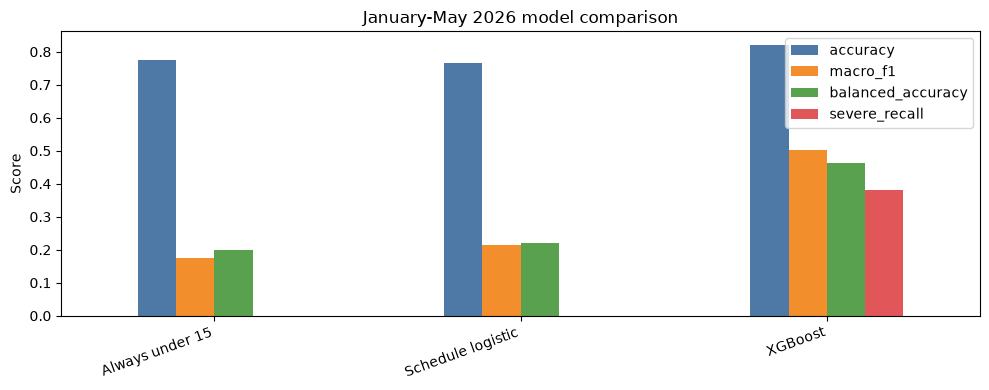

In [13]:
SCHEDULE_FEATURES = [
    "reporting_airline", "dest", "day_of_week", "scheduled_dep_hour",
    "scheduled_arr_hour", "month", "is_weekend", "hour_sin", "hour_cos",
    "month_sin", "month_cos", "days_until_holiday", "days_since_holiday",
    "scheduled_sfo_departures_same_hour",
    "scheduled_carrier_departures_same_hour",
    "distance_miles", "scheduled_elapsed_minutes",
]
schedule_categorical = ["reporting_airline", "dest"]
schedule_numeric = [
    feature
    for feature in SCHEDULE_FEATURES
    if feature not in schedule_categorical
]

def prepare_schedule_data(frame):
    schedule_data = frame[SCHEDULE_FEATURES].copy()
    schedule_data[schedule_numeric] = schedule_data[schedule_numeric].apply(
        pd.to_numeric,
        errors="coerce",
    )
    for column in schedule_categorical:
        schedule_data[column] = schedule_data[column].astype(object).where(
            schedule_data[column].notna(),
            np.nan,
        )
    return schedule_data

def build_schedule_preprocessor():
    return ColumnTransformer(
        [
            (
                "numeric",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="median")),
                        ("scale", StandardScaler()),
                    ]
                ),
                schedule_numeric,
            ),
            (
                "categorical",
                Pipeline(
                    [
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        (
                            "onehot",
                            OneHotEncoder(
                                handle_unknown="infrequent_if_exist",
                                min_frequency=25,
                                sparse_output=False,
                            ),
                        ),
                    ]
                ),
                schedule_categorical,
            ),
        ]
    )

def to_float32_dense(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype="float32")

def build_schedule_model(input_width):
    keras.utils.set_random_seed(CONFIG["seed"])
    schedule_model = keras.Sequential(
        [
            keras.Input(shape=(input_width,)),
            layers.Dense(len(CLASSES), activation="softmax"),
        ],
        name="schedule_softmax_regression",
    )
    schedule_model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.01),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return schedule_model

def select_schedule_epochs(
    training_frame,
    y_train,
    validation_frame,
    y_validation,
    epochs=40,
    batch_size=2048,
):
    preprocessor = build_schedule_preprocessor()
    X_train = to_float32_dense(
        preprocessor.fit_transform(prepare_schedule_data(training_frame))
    )
    X_validation = to_float32_dense(
        preprocessor.transform(prepare_schedule_data(validation_frame))
    )
    schedule_model = build_schedule_model(X_train.shape[1])
    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        restore_best_weights=True,
    )
    history = schedule_model.fit(
        X_train,
        y_train,
        sample_weight=make_sample_weights(y_train),
        validation_data=(
            X_validation,
            y_validation,
            make_sample_weights(y_validation),
        ),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
        callbacks=[early_stopping],
    )
    return int(np.argmin(history.history["val_loss"]) + 1)

def fit_schedule_model(
    training_frame,
    y_train,
    holdout_frame,
    epochs,
    batch_size=2048,
):
    preprocessor = build_schedule_preprocessor()
    X_train = to_float32_dense(
        preprocessor.fit_transform(prepare_schedule_data(training_frame))
    )
    X_holdout = to_float32_dense(
        preprocessor.transform(prepare_schedule_data(holdout_frame))
    )
    schedule_model = build_schedule_model(X_train.shape[1])
    schedule_model.fit(
        X_train,
        y_train,
        sample_weight=make_sample_weights(y_train),
        epochs=epochs,
        batch_size=batch_size,
        verbose=0,
    )
    return schedule_model.predict(X_holdout, verbose=0)

majority_probabilities = np.zeros((len(test), len(CLASSES)))
majority_probabilities[:, 0] = 1

chosen_schedule_epochs = select_schedule_epochs(
    train,
    y_train,
    validation,
    y_validation,
)
schedule_test_probabilities = fit_schedule_model(
    final_train,
    y_final_train,
    test,
    epochs=chosen_schedule_epochs,
)

comparison_rows = []
for model_name, feature_set, probabilities in [
    ("Always under 15", "No-skill", majority_probabilities),
    ("Schedule logistic", "17 schedule features", schedule_test_probabilities),
    (
        selected_model_name,
        f"{len(FEATURES)} tail-aware features",
        selected_test_probabilities,
    ),
]:
    comparison_rows.append(
        {
            "model": model_name,
            "feature_set": feature_set,
            **score_predictions(y_test, probabilities),
        }
    )

final_comparison = pd.DataFrame(comparison_rows).set_index("model")
display(final_comparison.round(4))

plot_metrics = final_comparison[
    ["accuracy", "macro_f1", "balanced_accuracy", "severe_recall"]
]
plot_metrics.plot.bar(
    figsize=(10, 4),
    color=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"],
)
plt.ylabel("Score")
plt.xlabel("")
plt.title("January-May 2026 model comparison")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


### Test confusion matrix and per-bin performance


,precision,recall,f1,support
under_15,0.8823,0.9512,0.9155,35320
15_to_under_60,0.5325,0.3758,0.4406,6741
60_to_under_120,0.4571,0.4032,0.4285,2314
120_to_under_240,0.5630,0.3436,0.4268,975
240_plus,0.4034,0.2399,0.3008,296


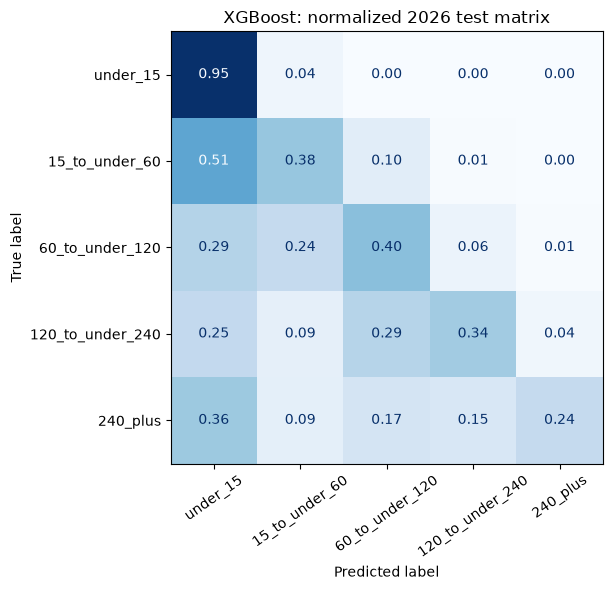

In [14]:
test_predictions = selected_test_probabilities.argmax(axis=1)
precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    test_predictions,
    labels=CLASSES,
    zero_division=0,
)
per_bin_results = pd.DataFrame(
    {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
    },
    index=LABELS,
)
display(per_bin_results.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    test_predictions,
    labels=CLASSES,
    display_labels=LABELS,
    normalize="true",
    cmap="Blues",
    values_format=".2f",
    xticks_rotation=35,
    colorbar=False,
    ax=ax,
)
ax.set_title(f"{selected_model_name}: normalized 2026 test matrix")
plt.tight_layout()
plt.show()


### User facing cumulative delay probabilities

These metrics treat the five-bin model as binary warnings: at least 15, 60, 120, or 240 minutes late.

These probabilities may be easier for a traveler to use than five separate bins: chance of at least 15 minutes, at least 1 hour, at least 2 hours, and at least 4 hours late.


In [15]:
cumulative_probabilities = np.column_stack(
    [
        selected_test_probabilities[:, 1:].sum(axis=1),
        selected_test_probabilities[:, 2:].sum(axis=1),
        selected_test_probabilities[:, 3:].sum(axis=1),
        selected_test_probabilities[:, 4],
    ]
)

threshold_rows = []
for index, threshold in enumerate(CONFIG["bin_edges_minutes"]):
    actual = y_test >= index + 1
    risk = cumulative_probabilities[:, index]
    predicted = risk >= 0.5 # cutoff
    threshold_rows.append(
        {
            "threshold": f">={threshold} min",
            "percent_of_data": actual.mean(),
            "binary_accuracy_at_50pct_cutoff": accuracy_score(actual, predicted),
            "f1_at_0.5": f1_score(actual, predicted, zero_division=0),
            "PR_AUC": average_precision_score(actual, risk),
            "ROC_AUC": roc_auc_score(actual, risk),
        }
    )

threshold_results = pd.DataFrame(threshold_rows).set_index("threshold")
display(threshold_results.round(4))


,percent_of_data,binary_accuracy_at_50pct_cutoff,f1_at_0.5,PR_AUC,ROC_AUC
threshold,,,,,
>=15 min,0.2262,0.8337,0.6430,0.7435,0.8494
>=60 min,0.0785,0.9416,0.6048,0.6283,0.8748
>=120 min,0.0278,0.9778,0.4702,0.4946,0.8929
>=240 min,0.0065,0.9935,0.2680,0.2287,0.8571


The binary accuracy column uses a 50% probability cutoff. This is easy to explain, but for rare severe delays PR-AUC and F1 are more informative than binary accuracy alone.

### XGBoost feature importance

,feature_importance
numeric__previous_arrived_by_cutoff,0.1791
numeric__previous_departed_by_cutoff,0.0964
categorical__reporting_airline_AA,0.0300
numeric__previous_flight_matches_origin,0.0262
numeric__previous_departure_delay_known,0.0257
numeric__scheduled_turnaround_minutes,0.0212
numeric__minutes_until_previous_scheduled_arrival,0.0173
categorical__dest_EWR,0.0161
numeric__tail_sequence_today,0.0157
categorical__reporting_airline_WN,0.0156


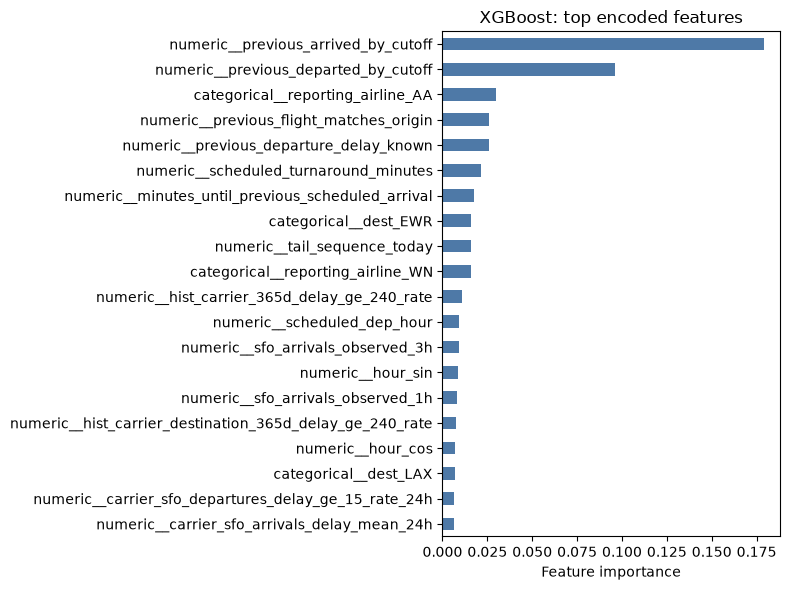

In [16]:
if hasattr(final_model, "feature_importances_"):
    encoded_feature_names = final_preprocessor.get_feature_names_out()
    feature_importance = pd.Series(
        final_model.feature_importances_,
        index=encoded_feature_names,
        name="feature_importance",
    ).sort_values(ascending=False).head(20)

    display(feature_importance.round(4).to_frame())
    feature_importance.sort_values().plot.barh(
        figsize=(8, 6),
        color="#4E79A7",
        xlabel="Feature importance",
    )
    plt.title(f"{selected_model_name}: top encoded features")
    plt.tight_layout()
    plt.show()


### Prediction horizon comparison

The selected model is also trained at the configured comparison horizon using the same feature contract. This isolates the value of changing how much recent operational and same-tail information is available.

Any primary horizon improvement over the comparison horizon is mostly a timing story. Later cutoffs make same-tail status and recent airport operations more informative.


In [17]:
primary_test_scores = score_predictions(y_test, selected_test_probabilities)

# Free memory
del X_train, X_validation, X_final_train, X_test
gc.collect()

required_comparison_columns = ["flight_date", "target_delay_bin", *FEATURES]
comparison_data = pd.read_parquet(
    ROOT / f"data/modeling/sfo_delay_features_{COMPARISON_HORIZON}h.parquet",
    columns=list(dict.fromkeys(required_comparison_columns)),
)
comparison_data = comparison_data.loc[comparison_data["target_delay_bin"].notna()]
comparison_train = comparison_data.loc[comparison_data["flight_date"] < TEST_START_DATE]
comparison_test = comparison_data.loc[comparison_data["flight_date"] >= TEST_START_DATE]
y_comparison_train = comparison_train["target_delay_bin"].astype(int).to_numpy()
y_comparison_test = comparison_test["target_delay_bin"].astype(int).to_numpy()

comparison_preprocessor = build_preprocessor()
X_comparison_train = comparison_preprocessor.fit_transform(prepare_model_data(comparison_train)).astype("float32")
X_comparison_test = comparison_preprocessor.transform(prepare_model_data(comparison_test)).astype("float32")

if selected_model_name == "Neural Network":
    (
        comparison_model,
        _,
        _,
        comparison_probabilities,
    ) = fit_neural_network(
        X_comparison_train,
        y_comparison_train,
        X_comparison_test,
        y_comparison_test,
        fit_weights=make_sample_weights(y_comparison_train),
        holdout_weights=make_sample_weights(y_comparison_test),
    )
else:
    comparison_model = clone(models[selected_model_name])
    comparison_model.fit(
        X_comparison_train,
        y_comparison_train,
        sample_weight=make_sample_weights(y_comparison_train),
    )
    comparison_probabilities = comparison_model.predict_proba(X_comparison_test)

comparison_test_scores = score_predictions(y_comparison_test, comparison_probabilities)

horizon_results = pd.DataFrame(
    {
        f"T-{PRIMARY_HORIZON}": primary_test_scores,
        f"T-{COMPARISON_HORIZON}": comparison_test_scores,
    }
).T
display(horizon_results.round(4))


,accuracy,balanced_accuracy,macro_f1,log_loss,within_one_bin,severe_recall
T-2,0.8209,0.4627,0.5024,0.6037,0.9688,0.3824
T-4,0.7951,0.3717,0.4068,0.6830,0.9523,0.2415
